In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
investor_data = pd.read_csv('C:\\Users\\roni2\\OneDrive\\Documents\\WSO - Python Fundementals\\Applied ML\\investor_data.csv')
investor_data.head(3)

,investor,commit,deal_size,invite,rating,int_rate,covenants,total_fees,fee_share,prior_tier,invite_tier
0,Goldman Sachs,Commit,300,40,2,Market,2,30,0.0,Participant,Bookrunner
1,Deutsche Bank,Decline,1200,140,2,Market,2,115,20.1,Bookrunner,Participant
2,Bank of America,Commit,900,130,3,Market,2,98,24.4,Bookrunner,Bookrunner


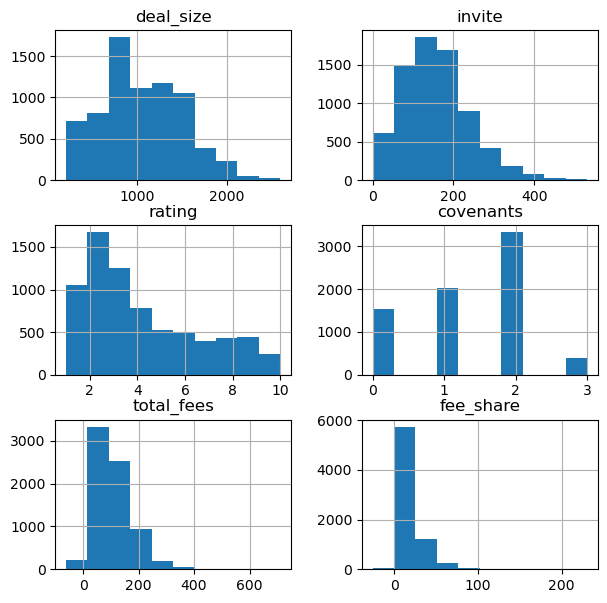

In [ ]:
#Display histogram to identify anomolies

investor_data.hist(figsize= (7,7))
plt.show()

In [ ]:
#Exclude data with total fees less than zero

investor_data = investor_data[investor_data['total_fees'] > 0]

investor_data
                            

,investor,commit,deal_size,invite,rating,int_rate,covenants,total_fees,fee_share,prior_tier,invite_tier
0,Goldman Sachs,Commit,300,40,2,Market,2,30,0.0,Participant,Bookrunner
1,Deutsche Bank,Decline,1200,140,2,Market,2,115,20.1,Bookrunner,Participant
2,Bank of America,Commit,900,130,3,Market,2,98,24.4,Bookrunner,Bookrunner
3,Wells Fargo,Commit,1200,210,2,Market,2,165,56.6,Bookrunner,Bookrunner
4,Wells Fargo,Commit,900,90,3,Market,3,161,38.5,Bookrunner,Participant
...,...,...,...,...,...,...,...,...,...,...,...
7284,Goldman Sachs,Commit,1000,140,10,Market,1,167,22.9,Bookrunner,Bookrunner
7285,Deutsche Bank,Decline,300,20,3,Below,2,29,1.5,Bookrunner,Participant
7286,Bank of America,Commit,800,130,1,Market,2,214,48.8,Bookrunner,Bookrunner
7287,Goldman Sachs,Decline,1700,110,5,Above,1,90,10.1,Bookrunner,Participant


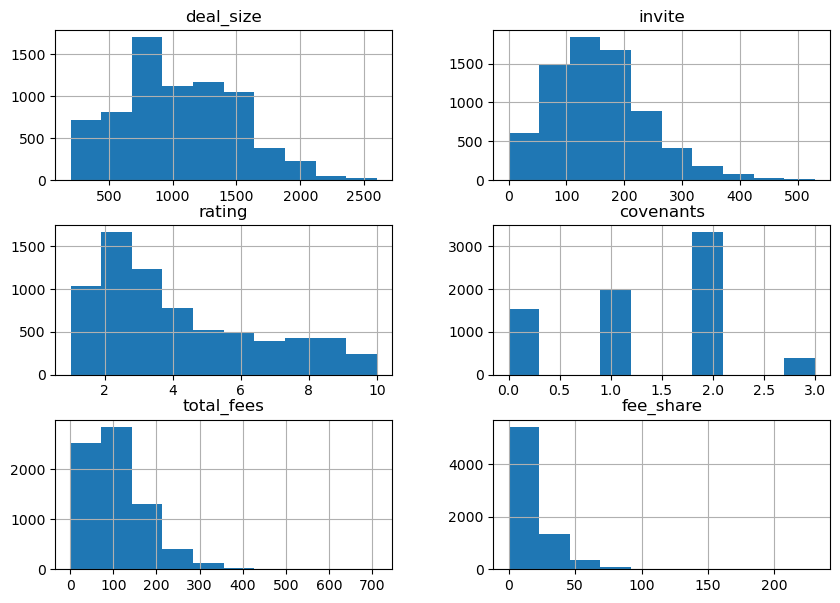

In [29]:
investor_data.hist(figsize = (10,7))
plt.show()

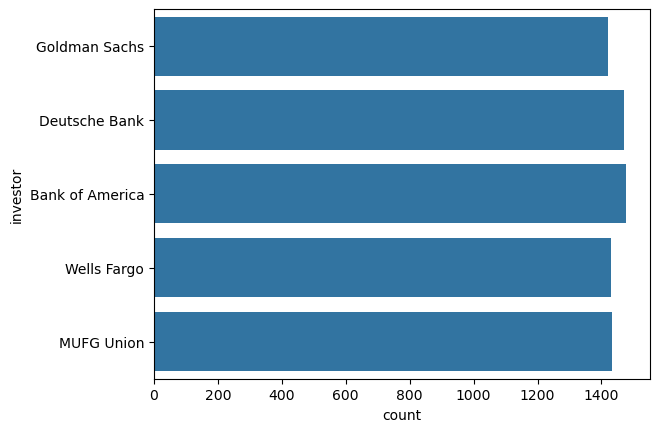

In [35]:
sns.countplot(y='investor', data=investor_data)
plt.show()

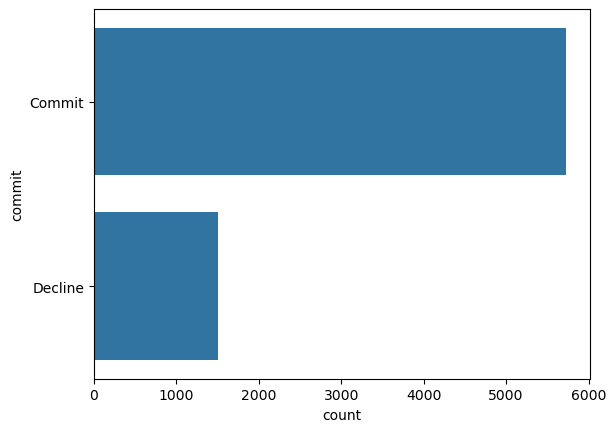

In [37]:
sns.countplot(y='commit', data=investor_data)
plt.show()

In [ ]:
investor_data.commit.value_counts()

commit
Commit     5730
Decline    1503
Name: count, dtype: int64

In [ ]:
#Record of Bank's commits and declines to provide a loan

investor_data.groupby('investor').commit.value_counts()

investor         commit 
Bank of America  Commit     1247
                 Decline     231
Deutsche Bank    Commit      940
                 Decline     531
Goldman Sachs    Commit     1064
                 Decline     356
MUFG Union       Commit     1207
                 Decline     226
Wells Fargo      Commit     1272
                 Decline     159
Name: count, dtype: int64

In [43]:
type(investor_data.groupby('investor').commit.value_counts())

pandas.core.series.Series

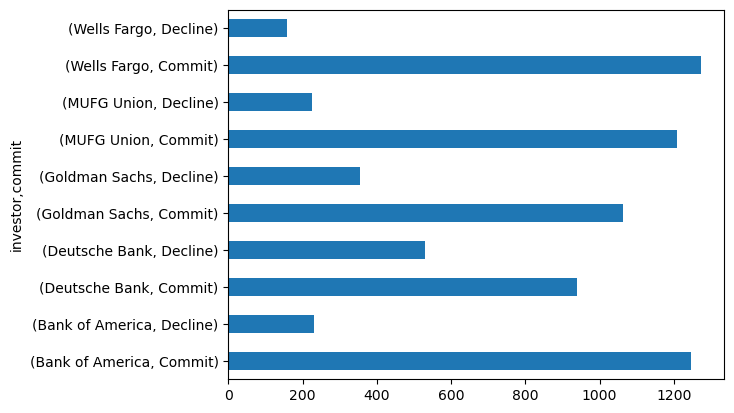

In [47]:
investor_data.groupby('investor').commit.value_counts().plot(kind='barh')
plt.show()

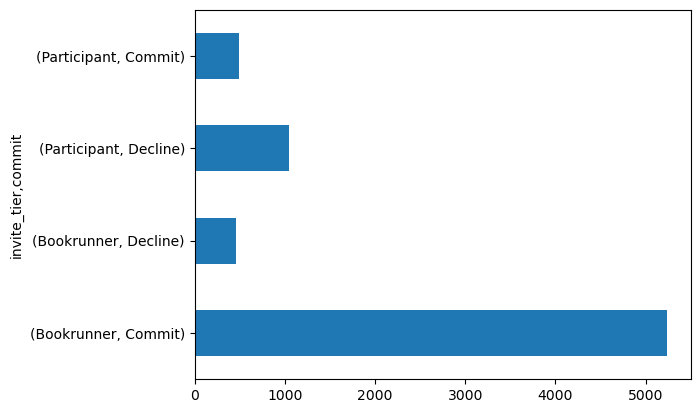

In [ ]:
#Invite tier, "Bookrunner" being leading loan provider and "participant" being a secondary loan provider (less active)

investor_data.groupby('invite_tier').commit.value_counts().plot(kind='barh')
plt.show()

In [ ]:
#Creates a column to identify which teir have been promoted, demoted or not changes 

investor_data['tier_change'] = np.where(
    investor_data.prior_tier == investor_data.invite_tier, 'None', np.where(
        investor_data.prior_tier == 'Participant', 'Promoted', 'Demoted'
    )
)

investor_data.head(3)

,investor,commit,deal_size,invite,rating,int_rate,covenants,total_fees,fee_share,prior_tier,invite_tier,tier_change
0,Goldman Sachs,Commit,300,40,2,Market,2,30,0.0,Participant,Bookrunner,Promoted
1,Deutsche Bank,Decline,1200,140,2,Market,2,115,20.1,Bookrunner,Participant,Demoted
2,Bank of America,Commit,900,130,3,Market,2,98,24.4,Bookrunner,Bookrunner,None


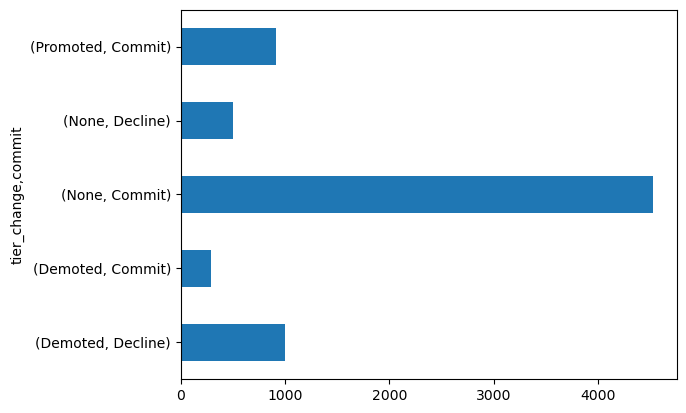

In [ ]:
#Comparison of commits to tier change

investor_data.groupby('tier_change').commit.value_counts().plot(kind = 'barh')
plt.show()

In [ ]:
#View commit count with no change to tier 

investor_data[investor_data.tier_change == 'None'].groupby('prior_tier').commit.value_counts()

prior_tier   commit 
Bookrunner   Commit     4322
             Decline     461
Participant  Commit      206
             Decline      43
Name: count, dtype: int64

In [ ]:
#Median count of commit for Goldman Sachs 

investor_data[investor_data.investor == 'Goldman Sachs'].groupby('commit').median(numeric_only = True)

,deal_size,invite,rating,covenants,total_fees,fee_share
commit,,,,,,
Commit,1100.0,170.0,3.0,1.5,107.0,14.35
Decline,900.0,100.0,3.0,2.0,68.0,5.65


In [ ]:
#Add columns to calculate the percentage of fees to total fees and percentage of invite to total deal size 

investor_data['fee_percent'] = investor_data.fee_share / investor_data.total_fees

investor_data['invite_percent'] = investor_data.invite / investor_data.deal_size

investor_data.head(3)


,investor,commit,deal_size,invite,rating,int_rate,covenants,total_fees,fee_share,prior_tier,invite_tier,tier_change,fee_percent,invite_percent
0,Goldman Sachs,Commit,300,40,2,Market,2,30,0.0,Participant,Bookrunner,Promoted,0.000000,0.133333
1,Deutsche Bank,Decline,1200,140,2,Market,2,115,20.1,Bookrunner,Participant,Demoted,0.174783,0.116667
2,Bank of America,Commit,900,130,3,Market,2,98,24.4,Bookrunner,Bookrunner,None,0.248980,0.144444


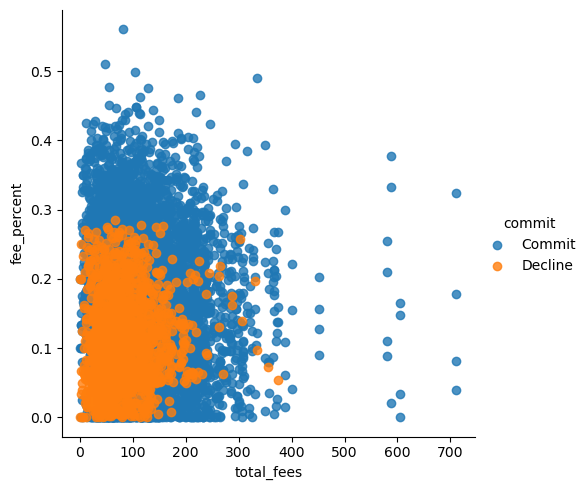

In [ ]:
#Plotting graph of total fees to fee percent, fee percentage greater than 0.3 have high commit rate

sns.lmplot(x='total_fees', y='fee_percent', hue='commit', data=investor_data, fit_reg=False)
plt.show()

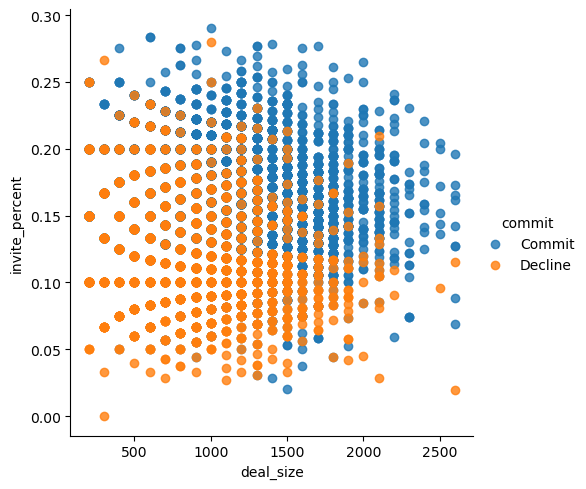

In [ ]:
#Plot of deal size to invite percentage, larger deal size with larger invite percentage has greater commit level.

sns.lmplot(x='deal_size', y='invite_percent', hue='commit', data=investor_data, fit_reg=False)
plt.show()